In [20]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1- Load DataSet

In [21]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("games.csv")
df.head(10)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Turkish']",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://www.ignibit.com/,office@ignibit.com,True,False,False,0,NaN,0,0,0,NaN,0,0,The trailer and the screenshots may contain co...,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1934300,Armored Brigade II,"Apr 8, 2025",0 - 20000,8,0,35.99,10,1,Building on the success of its acclaimed prede...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,support@slitherine.co.uk,True,False,False,0,NaN,0,117,13,NaN,0,107,NaN,675,0,1253,0,Veitikka Studios,Matrix Games,"Single-player,Steam Workshop,Steam Cloud,Famil...","Simulation,Strategy","Simulation,Strategy,RTS,Wargame,Grand Strategy...",https://shared.akamai.steamstatic.com/store_it...,NaN
700340,Galacatraz: Eject Equip Escape,"Feb 1, 2018",0 - 20000,0,0,0.99,0,0,"Years ago, Ricardo Luger was in the wrong plac...",['English'],['English'],NaN,https://shared.akamai.steams

## 2. Data Quality Assessment
### 2.1 Check Data Types

In [22]:
df.dtypes

AppID                          object
Name                           object
Release date                   object
Estimated owners                int64
Peak CCU                        int64
Required age                  float64
Price                           int64
DiscountDLC count               int64
About the game                 object
Supported languages            object
Full audio languages           object
Reviews                        object
Header image                   object
Website                        object
Support url                    object
Support email                  object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                 object
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int64
Recommendati

Some columns such as Release date may not be in datetime format.
Numerical columns like Price and Metacritic score must be numeric for proper analysis.

### 2.2 Convert Incorrect Data Types

In [23]:
df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Metacritic score'] = pd.to_numeric(df['Metacritic score'], errors='coerce')

df.dtypes

C:\Users\mooxx\AppData\Local\Temp\ipykernel_19112\358000769.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')


AppID                                 object
Name                                  object
Release date                  datetime64[ns]
Estimated owners                       int64
Peak CCU                               int64
Required age                         float64
Price                                  int64
DiscountDLC count                      int64
About the game                        object
Supported languages                   object
Full audio languages                  object
Reviews                               object
Header image                          object
Website                               object
Support url                           object
Support email                         object
Windows                                 bool
Mac                                     bool
Linux                                   bool
Metacritic score                       int64
Metacritic url                        object
User score                             int64
Positive  

## 3. Handling Missing Values

### Detect Missing Values

In [24]:
df.isna().sum()

AppID                              1
Name                               0
Release date                  122611
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
DiscountDLC count                  0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
Recommendations                    0
N

### Demonstration: Introduce Artificial Missing Values

In [25]:
df_missing = df.copy()

df_missing.iloc[0:6, df_missing.columns.get_loc('Price')] = np.nan

df_missing.isna().sum()

AppID                              1
Name                               0
Release date                  122611
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              6
DiscountDLC count                  0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
Recommendations                    0
N

## Strategy 1: Remove Records

In [26]:
df_removed = df_missing.dropna()
df_removed.shape

(0, 39)

## Strategy 2: Mean Imputation

In [27]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Price'].fillna(df_imputed_mean['Price'].mean(), inplace=True)
df_imputed_mean.isna().sum()

C:\Users\mooxx\AppData\Local\Temp\ipykernel_19112\1546420143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['Price'].fillna(df_imputed_mean['Price'].mean(), inplace=True)


AppID                              1
Name                               0
Release date                  122611
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
DiscountDLC count                  0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
Recommendations                    0
N

## Strategy 3: Median Imputation

In [28]:
df_imputed_median = df_missing.copy()
df_imputed_median['Price'].fillna(df_imputed_median['Price'].median(), inplace=True)
df_imputed_median.isna().sum()

C:\Users\mooxx\AppData\Local\Temp\ipykernel_19112\3700112836.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['Price'].fillna(df_imputed_median['Price'].median(), inplace=True)


AppID                              1
Name                               0
Release date                  122611
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
DiscountDLC count                  0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
Recommendations                    0
N

## 4. Handling Outliers

### Boxplot

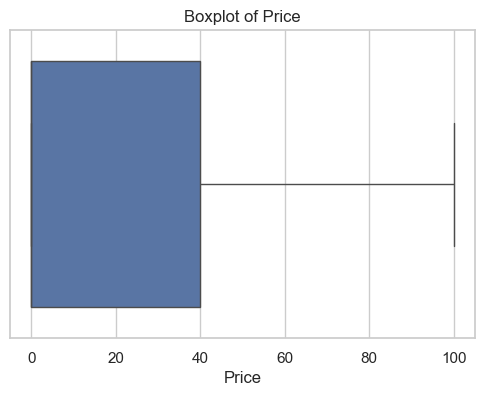

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")
plt.show()

### Detect Outliers using IQR

In [30]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
outliers.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies


### Remove Outliers

In [31]:
df_no_outliers = df[(df['Price'] >= lower) & (df['Price'] <= upper)]
print("Original shape: ", df.shape)
print("After removing outliers: ", df_no_outliers.shape)

Original shape:  (122611, 39)
After removing outliers:  (122611, 39)


## 5. Normalization

### Min-Max

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df[['Price','Metacritic score']].copy()
df_scaled[['Price','Metacritic score']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Price,Metacritic score
2539430,0.00,0.0
496350,0.65,0.0
1034400,0.00,0.0
3292190,0.00,0.0
3631080,0.00,0.0


### Z-Score

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['Price','Metacritic score']].copy()
df_standardized[['Price','Metacritic score']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Price,Metacritic score
2539430,-0.635980,-0.187763
496350,1.616361,-0.187763
1034400,-0.635980,-0.187763
3292190,-0.635980,-0.187763
3631080,-0.635980,-0.187763


### Correlation Before PCA

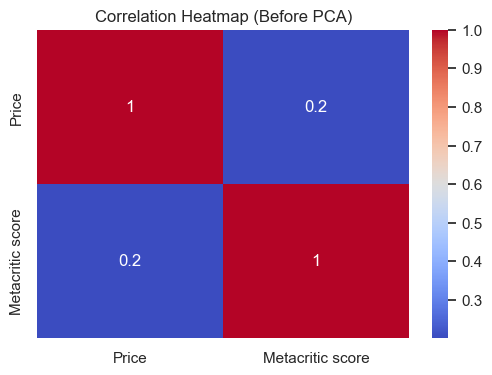

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Price','Metacritic score']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

### PCA

In [35]:
from sklearn.decomposition import PCA

X = df_standardized[['Price','Metacritic score']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.60089474 0.39910526]


### PCA Projection

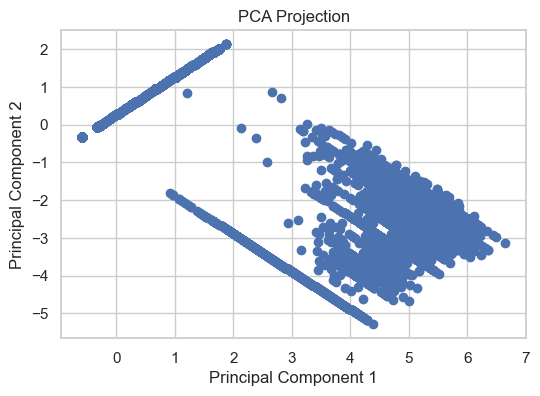

In [36]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()